In [ ]:
from utils_experiments import scale_to_range, simplified_cnn

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

2025-02-26 17:21:09.835943: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1740608470.144223     882 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1740608470.233169     882 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
seis_full= np.load('data/data_decatur/processed/seismic_exploration_block.npy')
seis_full.shape

(143, 370, 86)

In [3]:
X = seis_full
X = X.reshape(-1,86,1,1)
X_norm = scale_to_range(X)

In [ ]:
input_shape = (86, 1, 1)
model = simplified_cnn(input_shape)
print(model.summary())

I0000 00:00:1740608479.146167     882 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1414 MB memory:  -> device: 0, name: NVIDIA GeForce GT 1030, pci bus id: 0000:01:00.0, compute capability: 6.1


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 86, 1, 1)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 86, 1, 8)       │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 86, 1, 8)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 86, 1, 16)      │         1,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 86, 1, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 86, 1, 4)       │           964 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 86, 1, 4)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 86, 1, 4)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 344)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 344)            │       118,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 86, 1, 4)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 86, 1, 32)      │         1,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 86, 1, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 86, 1, 64)      │        30,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 86, 1, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 86, 1, 1)       │           961 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 86, 1, 1)       │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 155,405 (607.05 KB)

 Trainable params: 155,405 (607.05 KB)

 Non-trainable params: 0 (0.00 B)

None


In [5]:
model.load_weights('models/proposed.weights.h5')

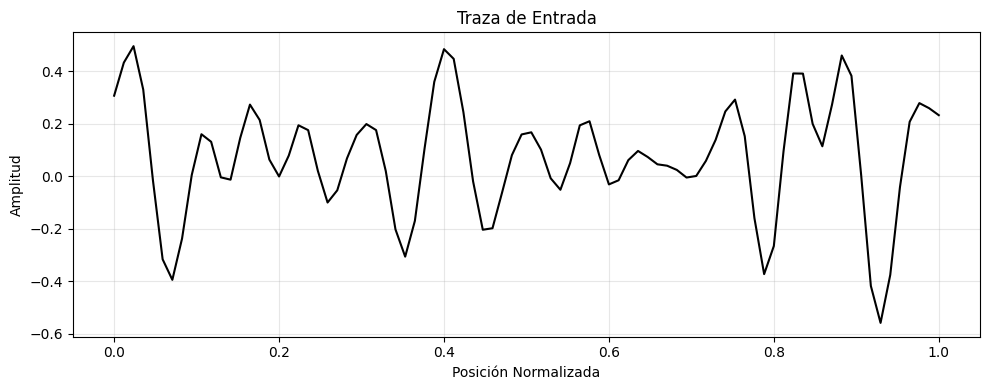

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 516ms/step


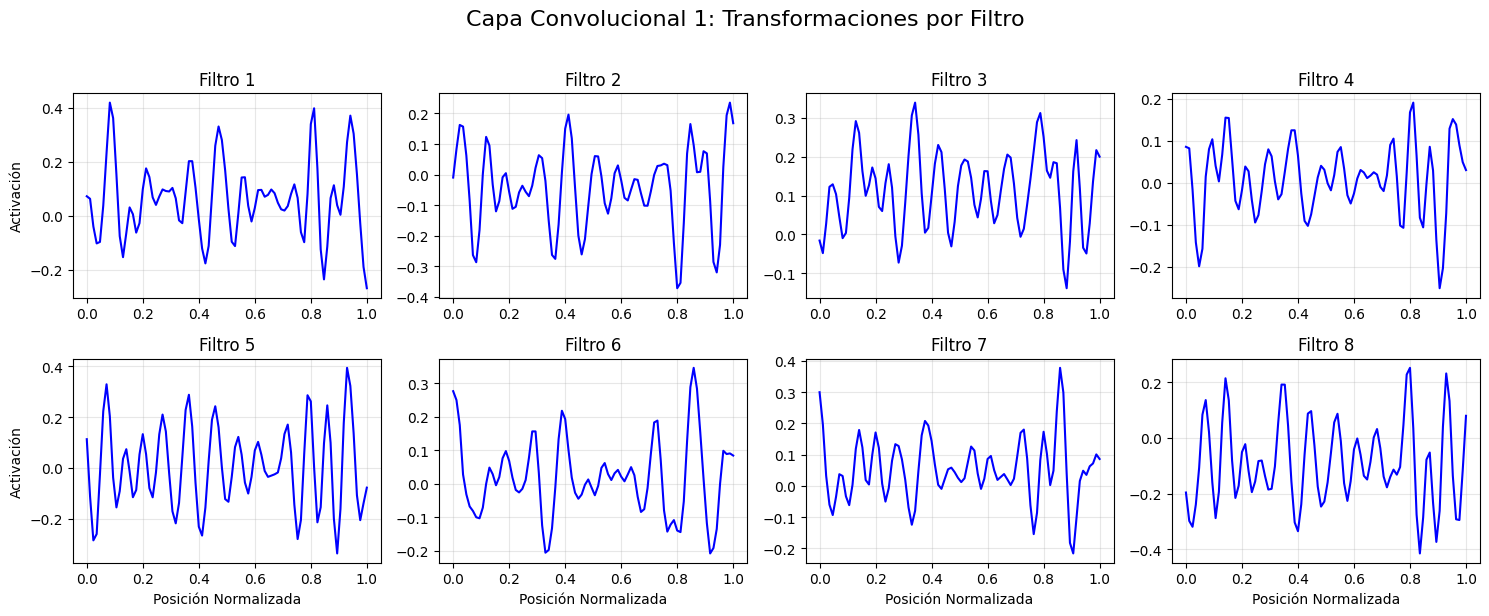

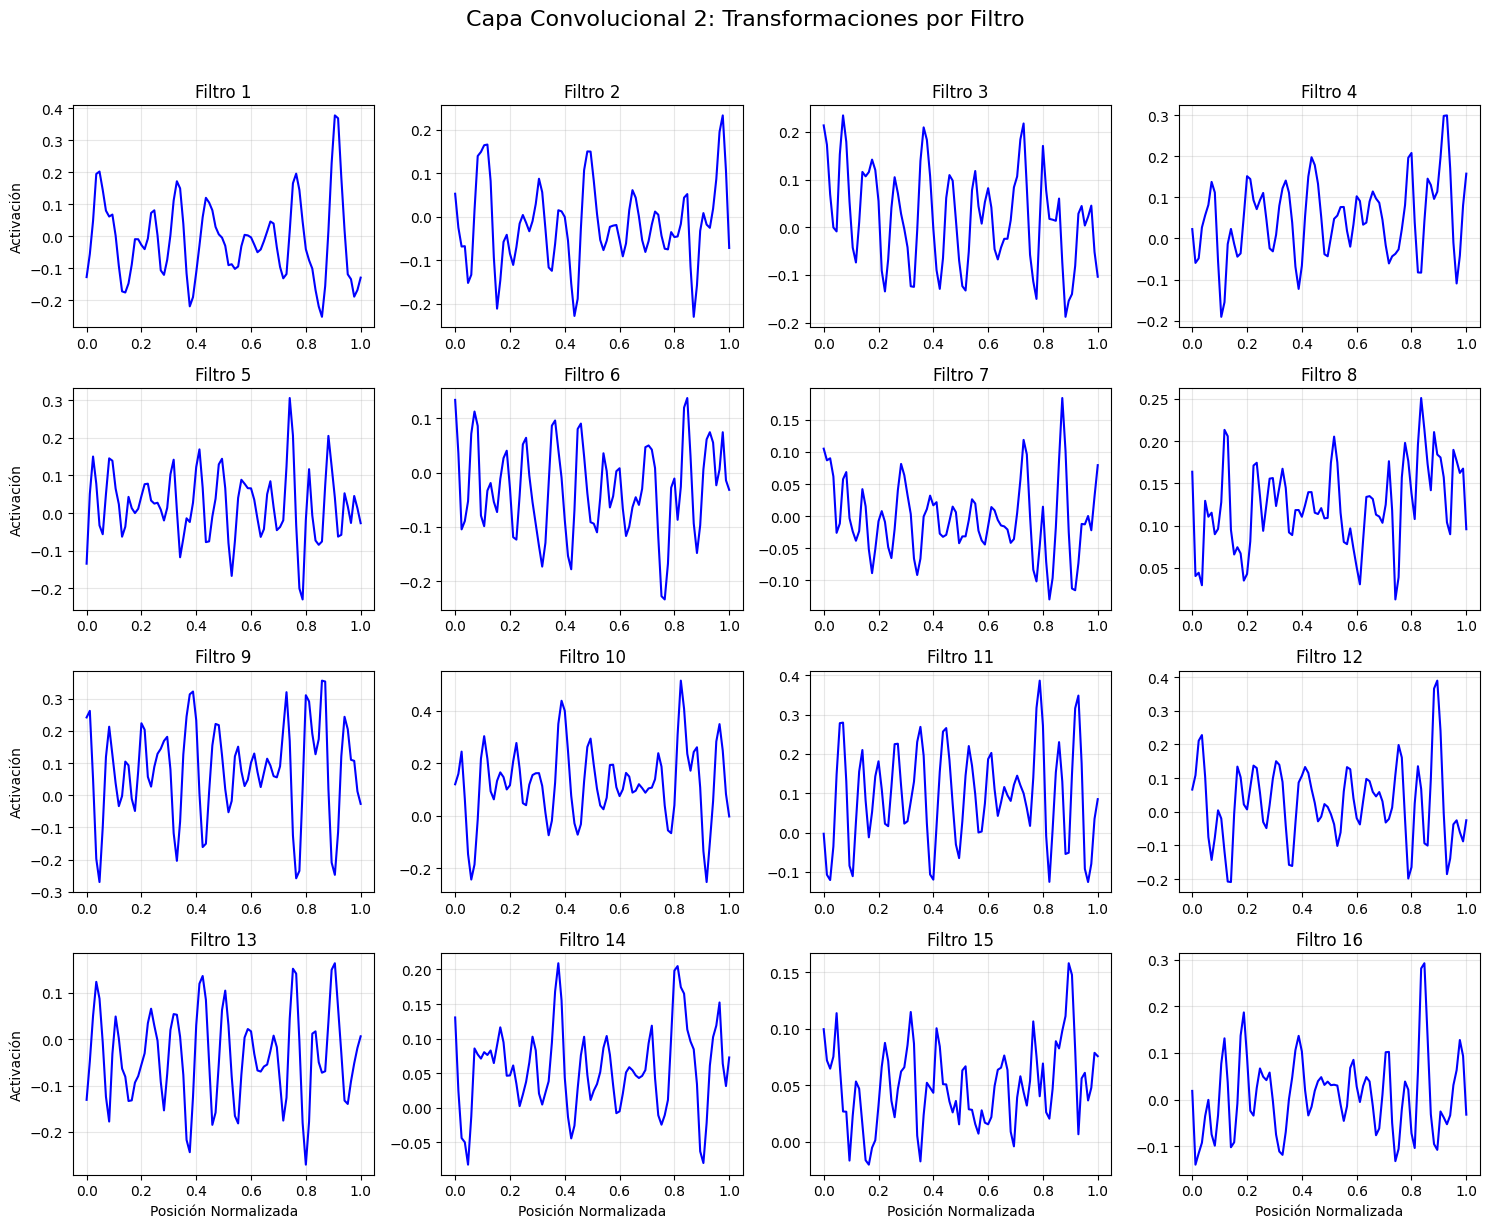

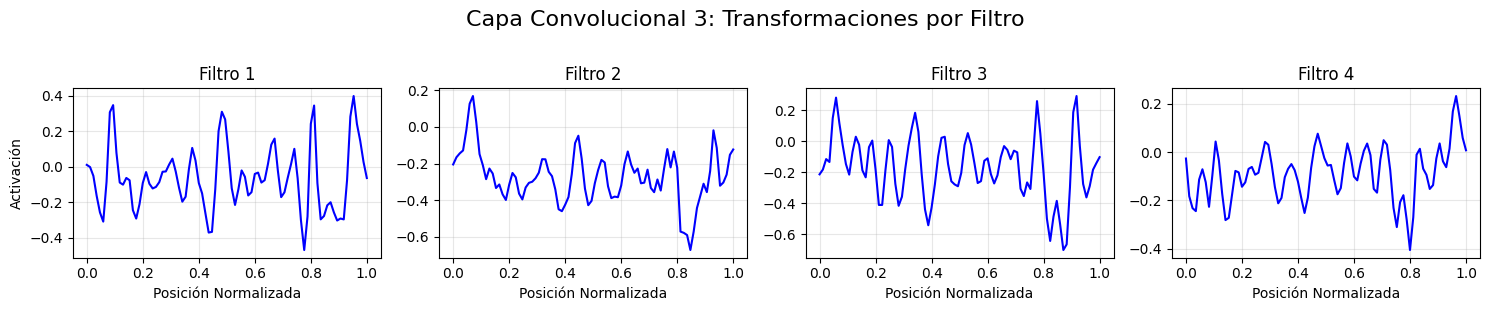

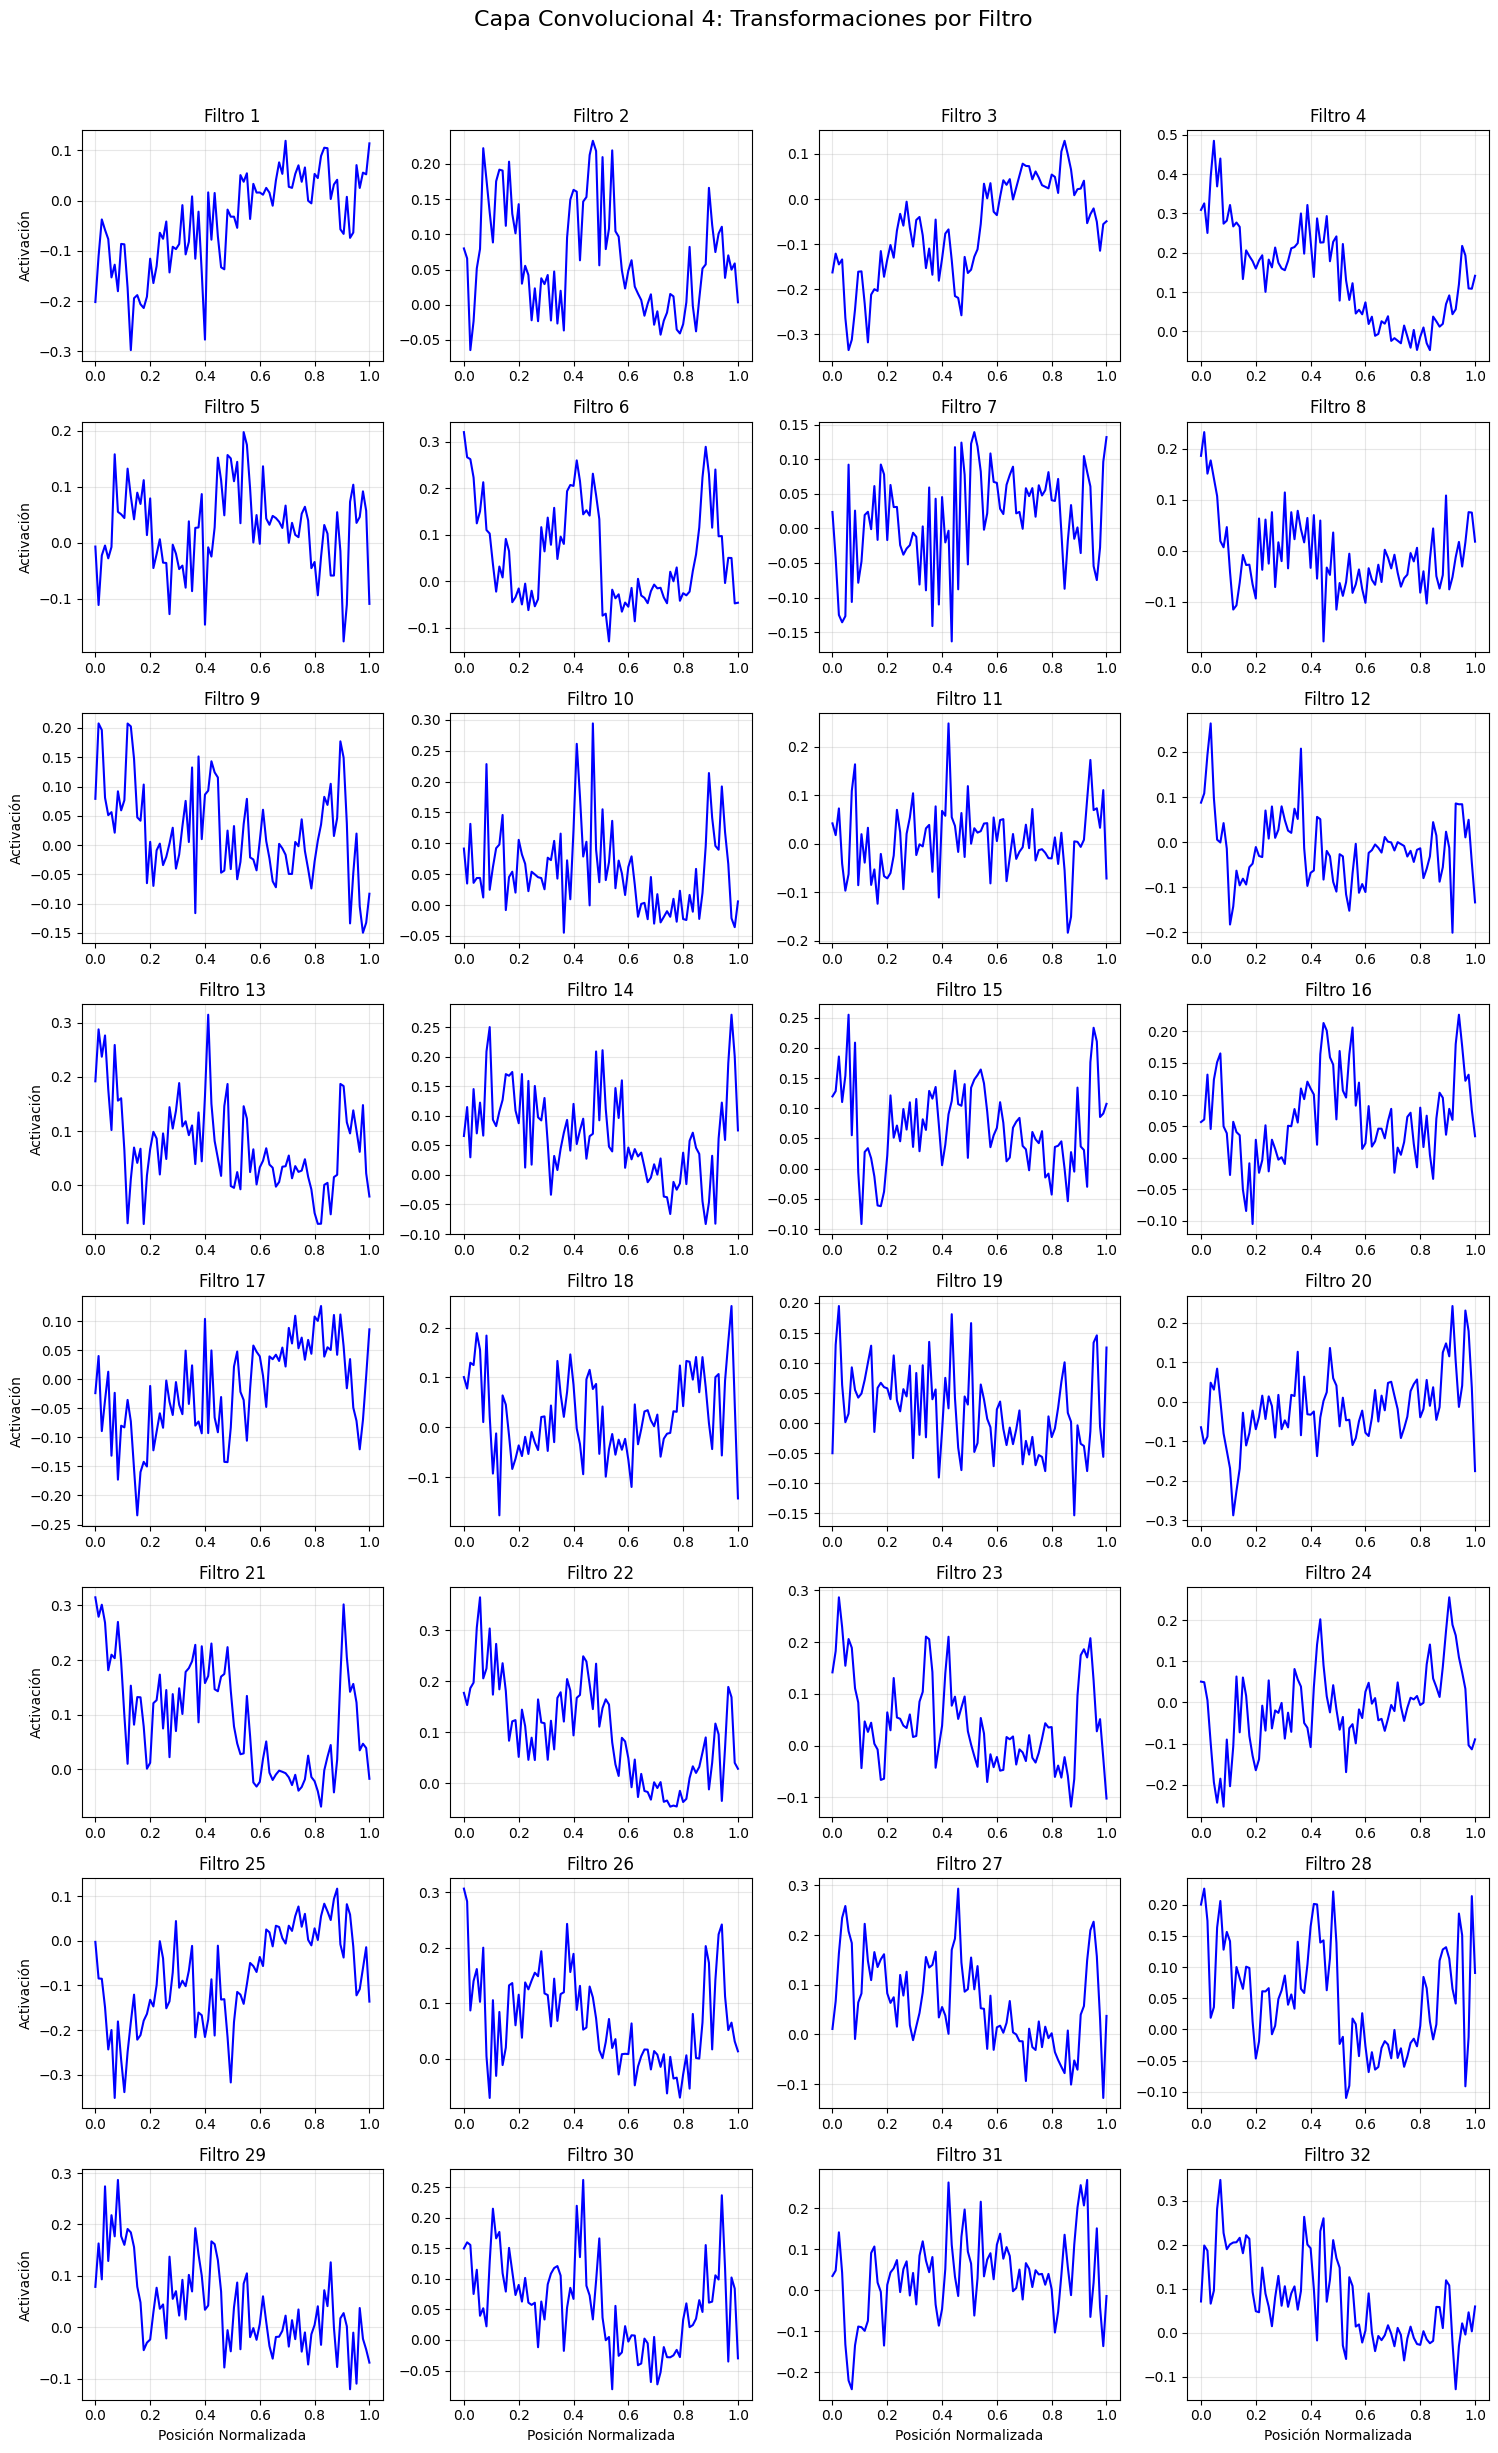

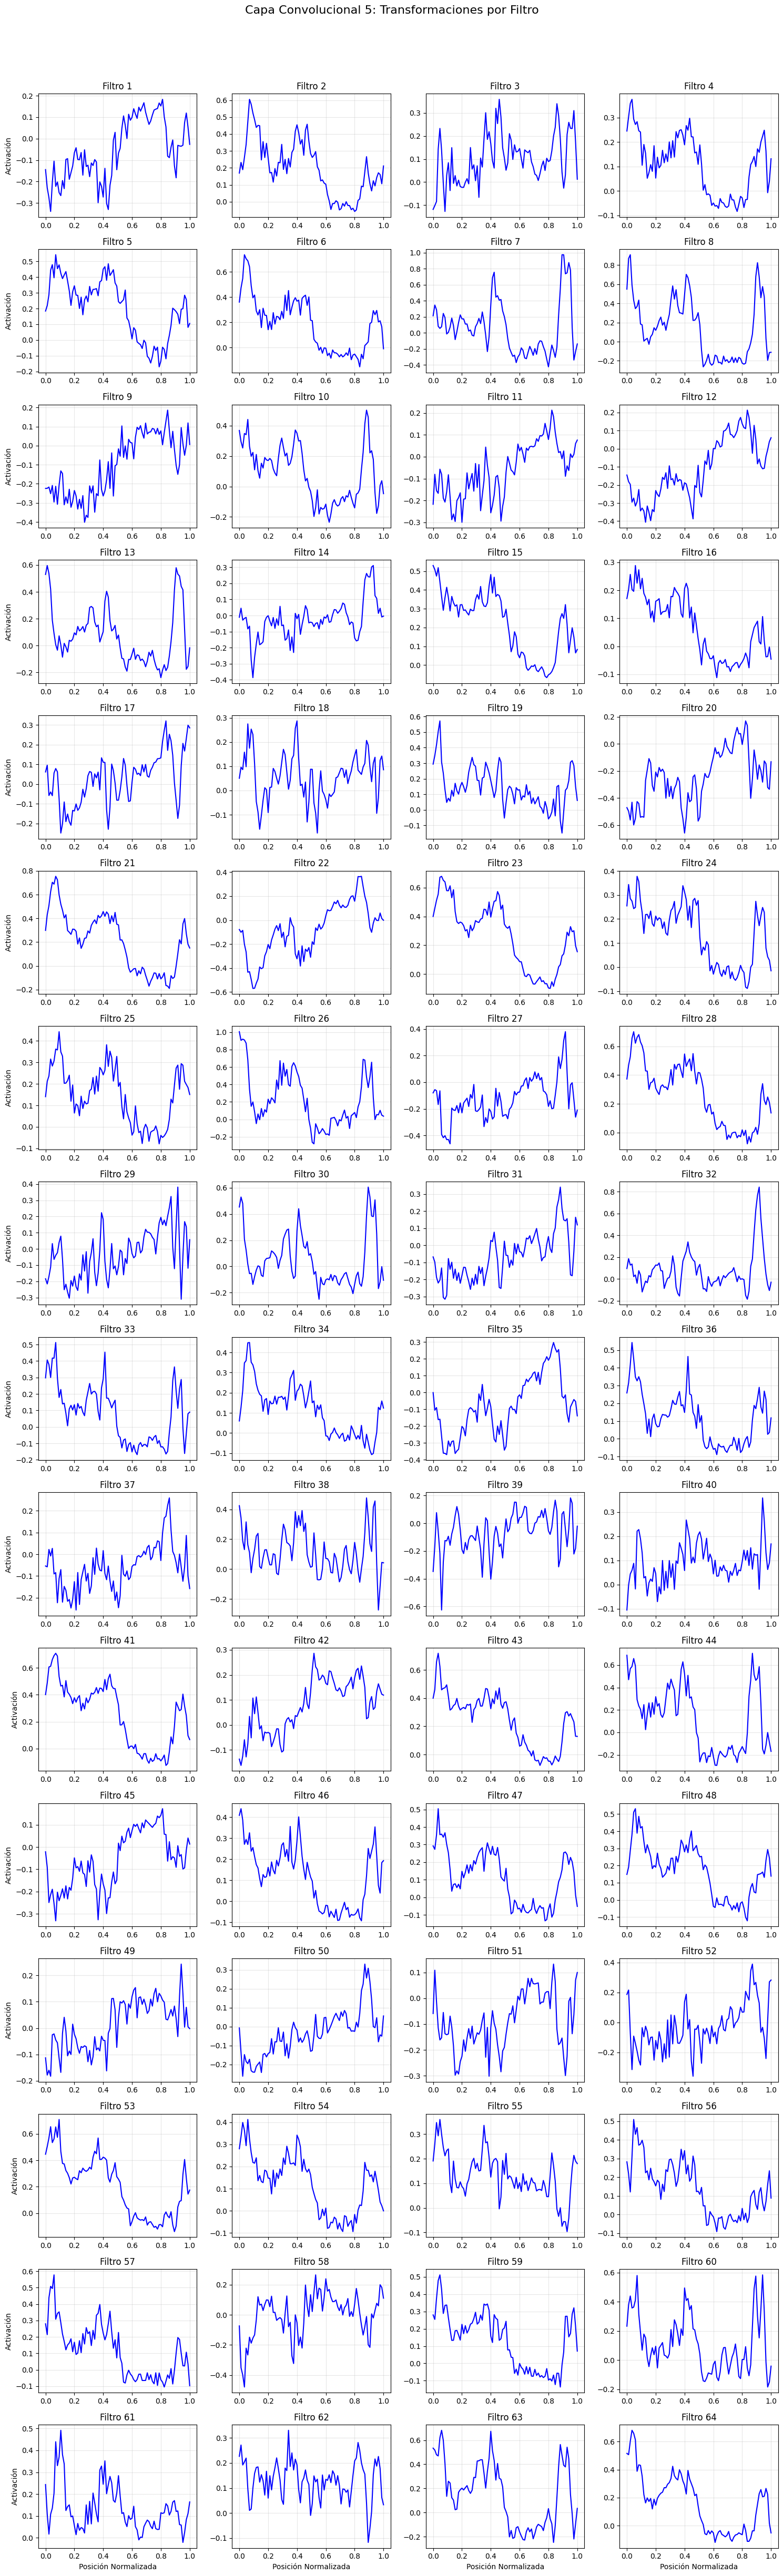

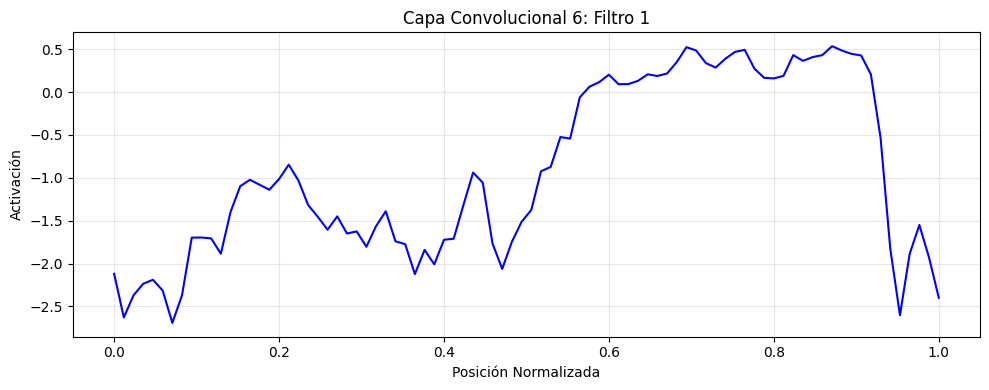

ModuleNotFoundError: No module named 'PyPDF2'

In [7]:
def visualize_single_trace_features(model, input_trace):
    # Crear directorio para guardar plots si no existe
    import os
    if not os.path.exists('plots'):
        os.makedirs('plots')
    
    # Primero graficar la traza de entrada y guardarla en PDF
    plt.figure(figsize=(10, 4))
    trace_data = np.squeeze(input_trace)
    x = np.linspace(0, 1, len(trace_data))
    plt.plot(x, trace_data, 'k-', linewidth=1.5)
    plt.title('Traza de Entrada')
    plt.grid(True, alpha=0.3)
    plt.xlabel('Posición Normalizada')
    plt.ylabel('Amplitud')
    plt.tight_layout()
    plt.savefig('plots/traza_entrada.pdf')
    plt.show()
    
    # Extraer las capas convolucionales
    conv_layer_outputs = []
    for layer in model.layers:
        if 'conv2d' in layer.name.lower():
            conv_layer_outputs.append(layer.output)
    
    # Crear modelo de activación
    activation_model = tf.keras.Model(inputs=model.input, outputs=conv_layer_outputs)
    
    # Obtener los feature maps
    fmaps = activation_model.predict(input_trace)
    
    # Visualizar los feature maps para cada capa convolucional
    for layer_idx, fmap in enumerate(fmaps):
        # Obtener dimensiones
        fmap_squeezed = np.squeeze(fmap, axis=0)
        num_filters = fmap_squeezed.shape[-1]
        sequence_length = fmap_squeezed.shape[0]
        
        # Manejar el caso especial de un solo filtro
        if num_filters == 1:
            fig, ax = plt.subplots(figsize=(10, 4))
            filter_signal = fmap_squeezed[:, 0, 0]
            x = np.linspace(0, 1, len(filter_signal))
            ax.plot(x, filter_signal, 'b-', linewidth=1.5)
            ax.set_title(f'Capa Convolucional {layer_idx + 1}: Filtro 1')
            ax.grid(True, alpha=0.3)
            ax.set_xlabel('Posición Normalizada')
            ax.set_ylabel('Activación')
            plt.tight_layout()
            # Guardar en PDF antes de mostrar
            plt.savefig(f'plots/feature_map_capa_{layer_idx + 1}.pdf')
            plt.show()
            continue
        
        # Para múltiples filtros, usar la lógica original
        num_cols = min(4, num_filters)
        num_rows = (num_filters + num_cols - 1) // num_cols
        
        fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 3*num_rows))
        fig.suptitle(f'Capa Convolucional {layer_idx + 1}: Transformaciones por Filtro', fontsize=16, y=1.02)
        
        # Convertir axes a 2D array si es necesario
        if num_rows == 1 and num_cols > 1:
            axes = np.array([axes])
        elif num_cols == 1 and num_rows > 1:
            axes = axes.reshape(-1, 1)
        elif num_rows == 1 and num_cols == 1:
            # Caso especial: solo un filtro pero no entró en la condición anterior
            axes = np.array([[axes]])
        
        # Plotear cada filtro en su propio subplot
        for filter_idx in range(num_filters):
            row = filter_idx // num_cols
            col = filter_idx % num_cols
            
            filter_signal = fmap_squeezed[:, 0, filter_idx]
            x = np.linspace(0, 1, len(filter_signal))
            
            axes[row, col].plot(x, filter_signal, 'b-', linewidth=1.5)
            axes[row, col].set_title(f'Filtro {filter_idx + 1}')
            axes[row, col].grid(True, alpha=0.3)
            
            if row == num_rows - 1:
                axes[row, col].set_xlabel('Posición Normalizada')
            if col == 0:
                axes[row, col].set_ylabel('Activación')
        
        # Ocultar ejes vacíos
        for idx in range(num_filters, num_rows * num_cols):
            row = idx // num_cols
            col = idx % num_cols
            if row < len(axes) and col < len(axes[0]):  # Verificar que el índice sea válido
                axes[row, col].set_visible(False)
        
        plt.tight_layout()
        # Guardar en PDF antes de mostrar
        plt.savefig(f'plots/feature_map_capa_{layer_idx + 1}.pdf')
        plt.show()

    # Guardar todos los PDFs en un solo archivo
    import os
    from PyPDF2 import PdfFileMerger
    
    try:
        merger = PdfFileMerger()
        
        # Primero añadir la traza de entrada
        merger.append('plots/traza_entrada.pdf')
        
        # Luego añadir todas las capas
        for layer_idx in range(len(fmaps)):
            merger.append(f'plots/feature_map_capa_{layer_idx + 1}.pdf')
        
        # Guardar el archivo combinado
        merger.write('plots/todas_las_capas.pdf')
        merger.close()
        print("Se ha creado un archivo PDF con todas las visualizaciones: plots/todas_las_capas.pdf")
    except Exception as e:
        print(f"No se pudo combinar los PDFs: {e}")
        print("Los archivos individuales siguen disponibles en la carpeta 'plots'")

# Uso de la función
single_trace = X_norm[0:1]  # Tomar la primera traza
visualize_single_trace_features(model, single_trace)